# Proyecto: selección de la mejor región para 200 pozos petrolíferos (OilyGiant)

## Objetivo general

Determinar en cuál de las tres regiones disponibles conviene abrir 200 pozos nuevos de petróleo, de manera que el beneficio esperado sea el más alto posible y el riesgo de pérdidas se mantenga por debajo del límite que fija la compañía.

Para llegar a esa decisión entrenamos un modelo de regresión lineal que predice el volumen de reservas de un pozo a partir de sus características geológicas, seleccionamos los pozos más prometedores de cada región y estimamos la distribución de beneficios con bootstrapping.

### Condiciones del negocio

| Condición | Valor |
| --- | --- |
| Presupuesto para el desarrollo | 100 000 000 USD |
| Pozos a desarrollar | 200 |
| Puntos explorados por región | 500 |
| Ingreso por unidad de producto (mil barriles) | 4 500 USD |
| Riesgo de pérdidas máximo aceptado | 2.5 % |
| Modelo permitido | Únicamente regresión lineal |

### Descripción de los datos

Cada región tiene su propio archivo (`geo_data_0`, `geo_data_1`, `geo_data_2`) con 100 000 pozos ya explorados:

- `id`: identificador del pozo.
- `f0`, `f1`, `f2`: tres características geológicas del punto. Su significado no se publica, pero son informativas.
- `product`: volumen de reservas en miles de barriles. Es la variable objetivo.

### Plan de trabajo

1. **Carga y preparación de los datos.** Revisar calidad, tipos y distribuciones de las tres regiones.
2. **Entrenamiento y prueba del modelo.** División 75:25, regresión lineal por región, volumen medio predicho y RMSE.
3. **Preparación del cálculo de ganancias.** Fijar las constantes del negocio y obtener el volumen mínimo por pozo que evita pérdidas.
4. **Cálculo del beneficio.** Función de beneficio sobre los 200 pozos con mayor predicción en cada región.
5. **Evaluación de riesgos con bootstrapping.** Distribución de beneficios, intervalo de confianza del 95 % y riesgo de pérdidas.

Al final se consolidan las conclusiones y se recomienda una región.

## Etapa 1: carga y preparación de los datos

**Objetivo:** cargar las tres regiones, verificar que los datos estén completos y en el tipo correcto, y comparar cómo se distribuyen las reservas en cada una.

In [46]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [47]:
def cargar_datos(nombre_archivo):
    try:
        datos = pd.read_csv(nombre_archivo)
    except FileNotFoundError:
        datos = pd.read_csv(f'/datasets/{nombre_archivo}')
    return datos


# cargamos las tres regiones y las guardamos en un diccionario para recorrerlas después
regiones = {
    'Región 0': cargar_datos('geo_data_0.csv'),
    'Región 1': cargar_datos('geo_data_1.csv'),
    'Región 2': cargar_datos('geo_data_2.csv'),
}

# revisamos las primeras filas de una región para confirmar la estructura
regiones['Región 0'].head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [48]:
# Revisamos la estructura y los tipos de dato de cada región
for nombre, datos in regiones.items():
    print(f'===== {nombre} =====')
    datos.info()
    print()

===== Región 0 =====
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  str    
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), str(1)
memory usage: 4.3 MB

===== Región 1 =====
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  str    
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), str(1)
memory usage: 4.3 MB

===== Región 2 =====
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):

In [49]:
# Verificamos la calidad de los datos: ausentes, filas repetidas e identificadores repetidos y lo almacenamos en un df
filas_calidad = []

for nombre, datos in regiones.items():
    filas_calidad.append(
        {
            'región': nombre,
            'filas': datos.shape[0],
            'valores_ausentes': datos.isna().sum().sum(),
            'filas_duplicadas': datos.duplicated().sum(),
            'ids_repetidos': datos['id'].duplicated().sum(),
        }
    )

calidad = pd.DataFrame(filas_calidad).set_index('región')

calidad

,filas,valores_ausentes,filas_duplicadas,ids_repetidos
región,,,,
Región 0,100000,0,0,10
Región 1,100000,0,0,4
Región 2,100000,0,0,4


In [50]:
# Miramos de cerca los identificadores repetidos para decidir qué hacer con ellos
ejemplo = regiones['Región 0']
ids_repetidos = ejemplo.loc[ejemplo['id'].duplicated(keep=False)].sort_values('id')

ids_repetidos.head(6)

,id,f0,f1,f2,product
64022,74z30,0.741456,0.459229,5.153109,140.771492
66136,74z30,1.084962,-0.312358,6.990771,127.643327
3389,A5aEY,-0.039949,0.156872,0.209861,89.249364
51970,A5aEY,-0.180335,0.935548,-2.094773,33.020205
42529,AGS9W,1.454747,-0.479651,0.683380,126.370504
69163,AGS9W,-0.933795,0.116194,-3.655896,19.230453


Los identificadores se repiten, pero las filas no: cada una tiene características y volumen distintos. Se trata de pozos diferentes que comparten un identificador, no de registros cargados dos veces, así que no eliminamos nada. La columna `id` tampoco entra al modelo porque no aporta información geológica.

In [51]:
# Comparamos las estadísticas de las reservas (product) entre regiones
estadisticas = pd.DataFrame()

for nombre, datos in regiones.items():
    resumen = datos['product'].describe()
    # agregamos cuántos valores distintos toma el objetivo
    resumen['valores_únicos'] = datos['product'].nunique()
    estadisticas[nombre] = resumen

estadisticas

,Región 0,Región 1,Región 2
count,100000.000000,100000.000000,100000.000000
mean,92.500000,68.825000,95.000000
std,44.288691,45.944423,44.749921
min,0.000000,0.000000,0.000000
25%,56.497507,26.953261,59.450441
50%,91.849972,57.085625,94.925613
75%,128.564089,107.813044,130.595027
max,185.364347,137.945408,190.029838
valores_únicos,100000.000000,12.000000,100000.000000


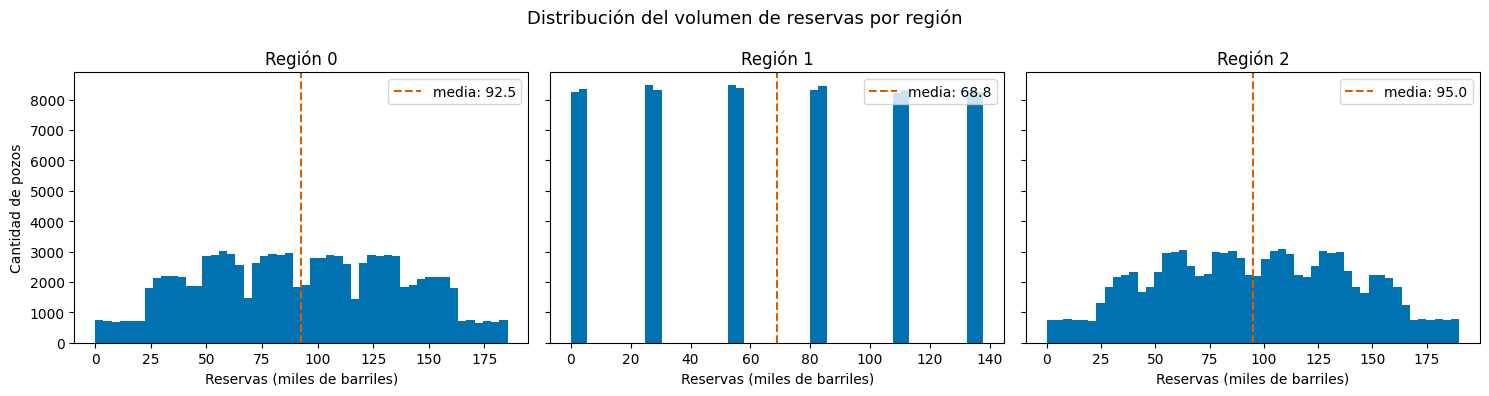

In [52]:
# Graficamos la distribución de las reservas para ver en qué se diferencian las regiones
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (nombre, datos) in zip(axes, regiones.items()):
    media = datos['product'].mean()
    ax.hist(datos['product'], bins=50, color='#0072B2')
    ax.axvline(media, color='#D55E00', linestyle='--', label=f'media: {media:.1f}')
    ax.set_title(nombre)
    ax.set_xlabel('Reservas (miles de barriles)')
    ax.legend()

axes[0].set_ylabel('Cantidad de pozos')
fig.suptitle('Distribución del volumen de reservas por región', fontsize=13)
fig.tight_layout()
plt.show()

In [53]:
# Imprimimos el resumen numérico de la etapa
print('Resumen de la etapa 1')
print('-' * 60)
for nombre, datos in regiones.items():
    reservas = datos['product']
    print(
        f'{nombre}: {datos.shape[0]} pozos | '
        f'media {reservas.mean():.2f} | desviación {reservas.std():.2f} | '
        f'mínimo {reservas.min():.2f} | máximo {reservas.max():.2f} | '
        f'pozos sin reservas (0) {(reservas == 0).sum()}'
    )

Resumen de la etapa 1
------------------------------------------------------------
Región 0: 100000 pozos | media 92.50 | desviación 44.29 | mínimo 0.00 | máximo 185.36 | pozos sin reservas (0) 1
Región 1: 100000 pozos | media 68.83 | desviación 45.94 | mínimo 0.00 | máximo 137.95 | pozos sin reservas (0) 8235
Región 2: 100000 pozos | media 95.00 | desviación 44.75 | mínimo 0.00 | máximo 190.03 | pozos sin reservas (0) 1


**Conclusión de la etapa 1:** las tres regiones traen 100 000 pozos cada una, sin valores ausentes ni filas duplicadas, y todas las columnas llegan con el tipo correcto, así que no hubo que limpiar nada. Los identificadores repetidos (10 en la región 0, 4 en las regiones 1 y 2) corresponden a pozos distintos, no a duplicados reales, y se conservan.

Las distribuciones sí marcan una diferencia importante. Las regiones 0 y 2 se comportan de forma parecida: reservas repartidas de manera continua, con medias de 92.50 y 95.00 miles de barriles, desviaciones de 44.29 y 44.75, y un solo pozo vacío en cada una.

La región 1 es un caso aparte. Su volumen de reservas toma solamente **12 valores distintos** en los 100 000 pozos (frente a casi 100 000 valores únicos en las otras dos), repartidos en grupos de unos 8 300 pozos cada uno; uno de esos valores es cero, y ahí caen 8 235 pozos. Su media es además la más baja: 68.83. Ese comportamiento casi discreto adelanta que allí las características describen el volumen de forma prácticamente exacta, lo que la etapa 2 debería confirmar con un RMSE muy bajo.

Vale la pena anotar desde ya que la media más alta no garantiza el mejor negocio: lo que decide el beneficio son los 200 pozos seleccionados, no el promedio de los 100 000.

## Etapa 2: entrenamiento y prueba del modelo

**Objetivo:** entrenar una regresión lineal por región con una división 75:25, y medir el volumen medio predicho y el RMSE en el conjunto de validación.

Siguiendo las instrucciones, primero recorremos el procedimiento completo sobre la región 0. Una vez comprobado que funciona, lo encapsulamos en una función y lo aplicamos a las tres regiones sin repetir el código.

In [54]:
# Separamos características y objetivo en la región 0
# la columna id queda fuera porque identifica al pozo, no describe su geología
datos_region_0 = regiones['Región 0']

caracteristicas = datos_region_0.drop(['id', 'product'], axis=1)
objetivo = datos_region_0['product']

# dividimos en entrenamiento y validación en proporción 75:25
caracteristicas_entrenamiento, caracteristicas_validacion, objetivo_entrenamiento, objetivo_validacion = train_test_split(
    caracteristicas, objetivo, test_size=0.25, random_state=12345
)

print('Tamaño del conjunto de entrenamiento:', caracteristicas_entrenamiento.shape[0])
print('Tamaño del conjunto de validación:', caracteristicas_validacion.shape[0])

Tamaño del conjunto de entrenamiento: 75000
Tamaño del conjunto de validación: 25000


In [55]:
# Entrenamos el modelo y predecimos sobre el conjunto de validación
modelo = LinearRegression()
modelo.fit(caracteristicas_entrenamiento, objetivo_entrenamiento)
predicciones = modelo.predict(caracteristicas_validacion)

# calculamos el RMSE como la raíz del error cuadrático medio
# tomamos la raíz con ** 0.5 en lugar del parámetro squared=False, que no está disponible en todas las versiones de sklearn
rmse = mean_squared_error(objetivo_validacion, predicciones) ** 0.5

print(f'Volumen medio de reservas predicho: {predicciones.mean():.2f} miles de barriles')
print(f'Volumen medio de reservas real: {objetivo_validacion.mean():.2f} miles de barriles')
print(f'RMSE: {rmse:.2f}')

Volumen medio de reservas predicho: 92.59 miles de barriles
Volumen medio de reservas real: 92.08 miles de barriles
RMSE: 37.58


El modelo acierta el promedio de la región (92.59 predicho contra 92.08 real), pero se equivoca en 37.58 miles de barriles en cada pozo individual. Como la desviación de las reservas es de 44.29, el modelo apenas reduce la incertidumbre frente a suponer siempre la media. Dicho de otro modo: sirve para ordenar pozos de mejor a peor, no para saber cuánto dará cada uno.

Ya validado el procedimiento, lo llevamos a una función.

In [56]:
# Encapsulamos todo lo anterior en una función para aplicarla a las tres regiones
def entrenar_y_evaluar(datos):
    caracteristicas = datos.drop(['id', 'product'], axis=1)
    objetivo = datos['product']

    caracteristicas_entrenamiento, caracteristicas_validacion, objetivo_entrenamiento, objetivo_validacion = train_test_split(
        caracteristicas, objetivo, test_size=0.25, random_state=12345
    )

    modelo = LinearRegression()
    modelo.fit(caracteristicas_entrenamiento, objetivo_entrenamiento)
    predicciones = modelo.predict(caracteristicas_validacion)

    # reiniciamos los índices para que las respuestas correctas y las predicciones queden alineadas
    objetivo_validacion = objetivo_validacion.reset_index(drop=True)
    predicciones = pd.Series(predicciones)

    return objetivo_validacion, predicciones

In [57]:
# Aplicamos la función a las tres regiones y guardamos las predicciones para las etapas siguientes
resultados = {}
filas_metricas = []

for nombre, datos in regiones.items():
    objetivo_validacion, predicciones = entrenar_y_evaluar(datos)
    resultados[nombre] = (objetivo_validacion, predicciones)

    filas_metricas.append(
        {
            'región': nombre,
            'volumen_medio_predicho': predicciones.mean(),
            'volumen_medio_real': objetivo_validacion.mean(),
            'rmse': mean_squared_error(objetivo_validacion, predicciones) ** 0.5,
            'desviación_real': objetivo_validacion.std(),
        }
    )

metricas = pd.DataFrame(filas_metricas).set_index('región')

metricas.round(2)

,volumen_medio_predicho,volumen_medio_real,rmse,desviación_real
región,,,,
Región 0,92.59,92.08,37.58,44.29
Región 1,68.73,68.72,0.89,46.02
Región 2,94.97,94.88,40.03,44.90


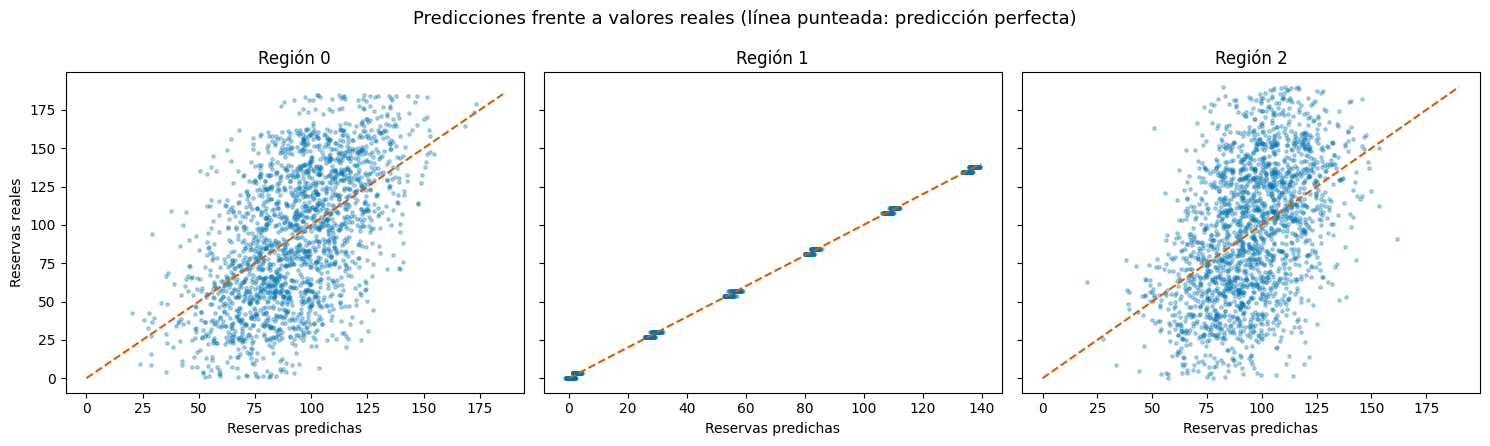

In [58]:
# Comparamos visualmente las predicciones contra los valores reales
# usamos una muestra de 2000 pozos por región para que el gráfico sea legible
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (nombre, (objetivo_validacion, predicciones)) in zip(axes, resultados.items()):
    muestra = predicciones.sample(2000, random_state=12345).index

    ax.scatter(predicciones[muestra], objetivo_validacion[muestra], s=6, alpha=0.3, color='#0072B2')
    # la diagonal marca dónde caerían los puntos si el modelo fuera perfecto
    limite = max(objetivo_validacion.max(), predicciones.max())
    ax.plot([0, limite], [0, limite], color='#D55E00', linestyle='--', linewidth=1.5)
    ax.set_title(nombre)
    ax.set_xlabel('Reservas predichas')

axes[0].set_ylabel('Reservas reales')
fig.suptitle('Predicciones frente a valores reales (línea punteada: predicción perfecta)', fontsize=13)
fig.tight_layout()
plt.show()

In [59]:
# Imprimimos el resumen numérico de la etapa
print('Resumen de la etapa 2')
print('-' * 78)
for nombre in resultados:
    fila = metricas.loc[nombre]
    print(
        f'{nombre}: volumen medio predicho {fila["volumen_medio_predicho"]:.2f} | '
        f'real {fila["volumen_medio_real"]:.2f} | '
        f'RMSE {fila["rmse"]:.2f} | '
        f'RMSE como % de la desviación real {100 * fila["rmse"] / fila["desviación_real"]:.1f}%'
    )

Resumen de la etapa 2
------------------------------------------------------------------------------
Región 0: volumen medio predicho 92.59 | real 92.08 | RMSE 37.58 | RMSE como % de la desviación real 84.9%
Región 1: volumen medio predicho 68.73 | real 68.72 | RMSE 0.89 | RMSE como % de la desviación real 1.9%
Región 2: volumen medio predicho 94.97 | real 94.88 | RMSE 40.03 | RMSE como % de la desviación real 89.1%


**Conclusión de la etapa 2:** los resultados separan a la región 1 de las otras dos con claridad.

En las regiones 0 y 2 el modelo predice bien el promedio (92.59 y 94.97 frente a 92.08 y 94.88 reales), pero con un RMSE de 37.58 y 40.03, que equivale al 84.9 % y 89.1 % de la desviación de los datos. En el gráfico se ve como una nube ancha alrededor de la diagonal: el modelo distingue apenas si un pozo está por encima o por debajo del promedio.

En la región 1 el RMSE es de 0.89, un 2 % de su desviación. Los puntos caen prácticamente sobre la diagonal, agrupados en las 12 franjas que ya habíamos visto en la etapa 1. Ahí el modelo sí sabe cuánto va a producir cada pozo, aunque su volumen medio predicho sea el más bajo de las tres (68.73).

Esto plantea el dilema que resuelve el resto del proyecto: la región 1 ofrece menos petróleo en promedio pero predicciones confiables, mientras que las regiones 0 y 2 ofrecen más petróleo con predicciones imprecisas. Cuál conviene no se decide con el RMSE, sino con el dinero que produce la selección de los 200 mejores pozos.

## Etapa 3: preparación del cálculo de ganancias

**Objetivo:** dejar en variables las condiciones del negocio y obtener el volumen mínimo que debe producir un pozo para que la inversión no genere pérdidas. Ese umbral es la referencia contra la cual se mide todo lo que sigue.

In [60]:
# Guardamos en variables las condiciones del negocio
PRESUPUESTO = 100_000_000  # dólares disponibles para desarrollar los pozos
POZOS_DESARROLLADOS = 200  # pozos que se abren en la región elegida
PUNTOS_ESTUDIADOS = 500  # puntos que se exploran antes de elegir los 200 mejores
INGRESO_POR_UNIDAD = 4500  # dólares que genera cada unidad de producto (mil barriles)
UMBRAL_RIESGO = 0.025  # riesgo de pérdidas máximo que acepta la compañía

# Calculamos cuánto cuesta cada pozo y qué volumen necesita para cubrir ese costo
costo_por_pozo = PRESUPUESTO / POZOS_DESARROLLADOS
volumen_equilibrio = costo_por_pozo / INGRESO_POR_UNIDAD

print(f'Costo por pozo: {costo_por_pozo:,.0f} USD')
print(f'Volumen de equilibrio por pozo: {volumen_equilibrio:.2f} miles de barriles')

Costo por pozo: 500,000 USD
Volumen de equilibrio por pozo: 111.11 miles de barriles


In [61]:
# Comparamos el umbral de equilibrio con el volumen medio de reservas de cada región
filas_equilibrio = []

for nombre, datos in regiones.items():
    media = datos['product'].mean()
    filas_equilibrio.append(
        {
            'región': nombre,
            'volumen_medio': media,
            'volumen_equilibrio': volumen_equilibrio,
            'diferencia': media - volumen_equilibrio,
            'diferencia_%': 100 * (media - volumen_equilibrio) / volumen_equilibrio,
        }
    )

equilibrio = pd.DataFrame(filas_equilibrio).set_index('región')

equilibrio.round(2)

,volumen_medio,volumen_equilibrio,diferencia,diferencia_%
región,,,,
Región 0,92.50,111.11,-18.61,-16.75
Región 1,68.82,111.11,-42.29,-38.06
Región 2,95.00,111.11,-16.11,-14.50


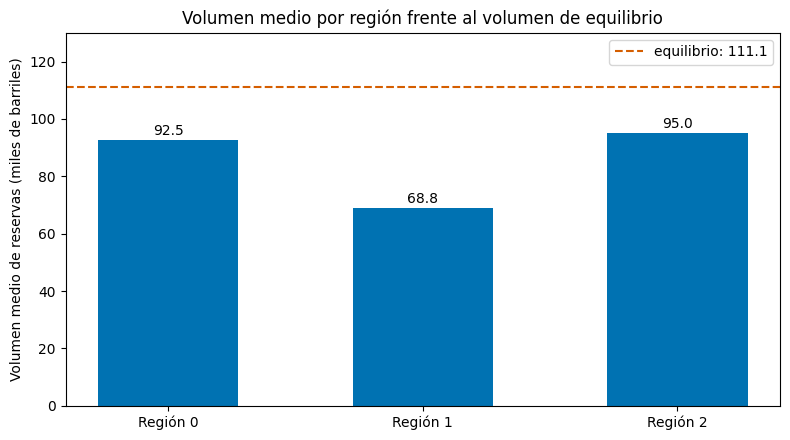

In [62]:
# Graficamos esa comparación para ver la distancia de cada región frente al umbral
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(equilibrio.index, equilibrio['volumen_medio'], color='#0072B2', width=0.55)
ax.axhline(volumen_equilibrio, color='#D55E00', linestyle='--',
           label=f'equilibrio: {volumen_equilibrio:.1f}')

# etiquetamos cada barra con su valor
for nombre, valor in equilibrio['volumen_medio'].items():
    ax.text(nombre, valor + 2, f'{valor:.1f}', ha='center')

ax.set_ylabel('Volumen medio de reservas (miles de barriles)')
ax.set_title('Volumen medio por región frente al volumen de equilibrio')
ax.set_ylim(0, 130)
ax.legend()
fig.tight_layout()
plt.show()

In [63]:
# Imprimimos el resumen numérico de la etapa
print('Resumen de la etapa 3')
print('-' * 72)
print(f'Presupuesto: {PRESUPUESTO:,} USD para {POZOS_DESARROLLADOS} pozos')
print(f'Costo por pozo: {costo_por_pozo:,.0f} USD')
print(f'Volumen de equilibrio: {volumen_equilibrio:.2f} miles de barriles por pozo')
print('-' * 72)
for nombre, fila in equilibrio.iterrows():
    print(
        f'{nombre}: volumen medio {fila["volumen_medio"]:.2f} | '
        f'diferencia frente al equilibrio {fila["diferencia"]:+.2f} ({fila["diferencia_%"]:+.1f}%)'
    )

Resumen de la etapa 3
------------------------------------------------------------------------
Presupuesto: 100,000,000 USD para 200 pozos
Costo por pozo: 500,000 USD
Volumen de equilibrio: 111.11 miles de barriles por pozo
------------------------------------------------------------------------
Región 0: volumen medio 92.50 | diferencia frente al equilibrio -18.61 (-16.8%)
Región 1: volumen medio 68.83 | diferencia frente al equilibrio -42.29 (-38.1%)
Región 2: volumen medio 95.00 | diferencia frente al equilibrio -16.11 (-14.5%)


**Conclusión de la etapa 3:** con 100 millones repartidos entre 200 pozos, cada pozo cuesta 500 000 dólares y necesita producir **111.11 miles de barriles** para devolver lo invertido.

Ninguna de las tres regiones llega a ese nivel en promedio: la región 2 se queda 16.11 unidades por debajo (-14.5 %), la región 0 se queda 18.61 (-16.8 %) y la región 1 se aleja 42.29 (-38.1 %). Un pozo promedio, en cualquiera de las tres, da pérdida.

De ahí que el proyecto no consista en escoger la región con más petróleo, sino en escoger bien los pozos: solo se desarrollan los 200 mejores de 500 puntos explorados, y esa selección tiene que levantar el volumen medio desde el rango de 69 a 95 hasta superar 111.11.

## Etapa 4: cálculo del beneficio de los 200 mejores pozos

**Objetivo:** escribir la función que calcula la ganancia de un conjunto de pozos seleccionados y aplicarla a las tres regiones, tomando en cada una los 200 pozos con la predicción más alta.

Un punto importante a acotar: la selección se hace con las predicciones del modelo, porque es lo único que se conoce antes de perforar, pero el beneficio se calcula con el volumen real de esos pozos, que es el petróleo que efectivamente se extrae.

In [64]:
# Definimos la función de beneficio: elige los mejores pozos según la predicción
# y calcula la ganancia con el volumen real que producen
def calcular_beneficio(objetivo, predicciones, n_pozos=POZOS_DESARROLLADOS):
    mejores = predicciones.sort_values(ascending=False).head(n_pozos).index
    volumen_real = objetivo[mejores].sum()
    ingreso = volumen_real * INGRESO_POR_UNIDAD
    return ingreso - PRESUPUESTO

In [65]:
# Aplicamos la función a las tres regiones usando las predicciones guardadas en la etapa 2
filas_beneficio = []

for nombre, (objetivo_validacion, predicciones) in resultados.items():
    beneficio = calcular_beneficio(objetivo_validacion, predicciones)
    # despejamos el volumen a partir del beneficio para no repetir la selección de pozos
    volumen_total = (beneficio + PRESUPUESTO) / INGRESO_POR_UNIDAD

    filas_beneficio.append(
        {
            'región': nombre,
            'volumen_total': volumen_total,
            'volumen_medio_por_pozo': volumen_total / POZOS_DESARROLLADOS,
            'ingreso': volumen_total * INGRESO_POR_UNIDAD,
            'beneficio': beneficio,
            'roi_%': 100 * beneficio / PRESUPUESTO,
        }
    )

beneficios = pd.DataFrame(filas_beneficio).set_index('región')

beneficios.round(2)

,volumen_total,volumen_medio_por_pozo,ingreso,beneficio,roi_%
región,,,,,
Región 0,29601.84,148.01,1.332083e+08,33208260.43,33.21
Región 1,27589.08,137.95,1.241509e+08,24150866.97,24.15
Región 2,28245.22,141.23,1.271035e+08,27103499.64,27.10


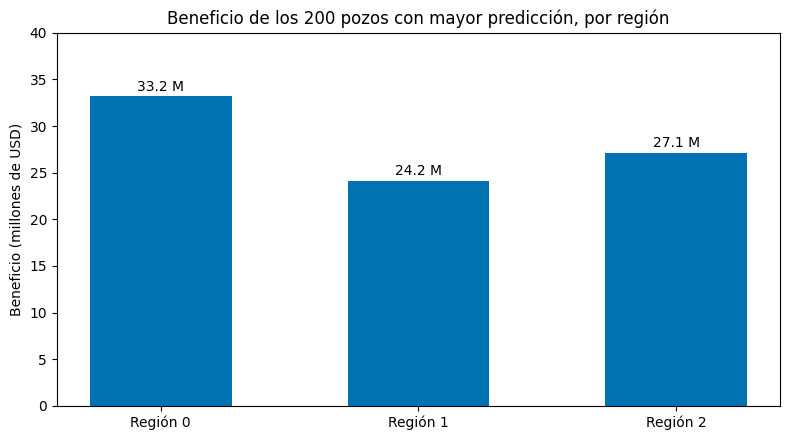

In [66]:
# Graficamos el beneficio potencial de cada región
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(beneficios.index, beneficios['beneficio'] / 1_000_000, color='#0072B2', width=0.55)

# etiquetamos cada barra con el beneficio en millones
for nombre, valor in (beneficios['beneficio'] / 1_000_000).items():
    ax.text(nombre, valor + 0.6, f'{valor:.1f} M', ha='center')

ax.set_ylabel('Beneficio (millones de USD)')
ax.set_title('Beneficio de los 200 pozos con mayor predicción, por región')
ax.set_ylim(0, 40)
fig.tight_layout()
plt.show()

In [67]:
# Imprimimos el resumen numérico de la etapa
print('Resumen de la etapa 4')
print('-' * 100)
for nombre, fila in beneficios.iterrows():
    print(
        f'{nombre}: volumen de los 200 pozos {fila["volumen_total"]:,.2f} | '
        f'promedio por pozo {fila["volumen_medio_por_pozo"]:.2f} | '
        f'beneficio {fila["beneficio"]:,.0f} USD | ROI {fila["roi_%"]:.1f}%'
    )

Resumen de la etapa 4
----------------------------------------------------------------------------------------------------
Región 0: volumen de los 200 pozos 29,601.84 | promedio por pozo 148.01 | beneficio 33,208,260 USD | ROI 33.2%
Región 1: volumen de los 200 pozos 27,589.08 | promedio por pozo 137.95 | beneficio 24,150,867 USD | ROI 24.2%
Región 2: volumen de los 200 pozos 28,245.22 | promedio por pozo 141.23 | beneficio 27,103,500 USD | ROI 27.1%


**Conclusión de la etapa 4:** seleccionar los mejores pozos cambia el panorama por completo. El volumen medio de los 200 elegidos sube a 148.01, 137.95 y 141.23 miles de barriles en las regiones 0, 1 y 2, muy por encima de las medias generales (92.50, 68.83 y 95.00) y del umbral de equilibrio de 111.11. Las tres regiones dejan de dar pérdida.

En beneficio, el orden queda así:

| Región | Beneficio | ROI |
| --- | --- | --- |
| Región 0 | 33 208 260 USD | 33.2 % |
| Región 2 | 27 103 500 USD | 27.1 % |
| Región 1 | 24 150 867 USD | 24.2 % |

Con esta información la candidata sería la región 0. El salto de la región 1 es notable. Pasa de la peor media general a 137.95 por pozo gracias a que su modelo predice casi sin error, pero su techo la deja de última: su volumen máximo es 137.95, así que ni seleccionando perfectamente puede competir con los 148.01 de la región 0.

Ahora bien, este cálculo tiene un supuesto que no se cumple en la práctica: elige los 200 mejores entre los 25 000 pozos del conjunto de validación, mientras que la compañía solo explora 500 puntos antes de decidir. Cuanto más grande es el conjunto donde se busca, mejores son los pozos que aparecen, así que estas cifras son un techo optimista y no dicen mucho sobre el riesgo.

## Etapa 5: cálculo de riesgos y ganancias con bootstrapping

**Objetivo:** estimar la distribución de beneficios de cada región en las condiciones reales del negocio y medir el riesgo de pérdidas.

La etapa 4 eligió los 200 mejores pozos entre los 25 000 del conjunto de validación, pero la compañía solo explora 500 puntos antes de decidir. Con bootstrapping repetimos 1 000 veces ese escenario: tomamos submuestras de 500 pozos con reemplazo, aplicamos sobre cada una la misma función de beneficio y observamos cómo se distribuyen los 1 000 resultados. De esa distribución salen el beneficio promedio, el intervalo de confianza del 95 % y la probabilidad de perder dinero.

In [68]:
# Definimos la función que repite 1 000 veces el escenario real de exploración
def analizar_riesgo(objetivo, predicciones, n_submuestras=1000):
    # el estado aleatorio cambia en cada llamada, así cada submuestra es distinta
    estado = np.random.RandomState(12345)
    beneficios = []

    for _ in range(n_submuestras):
        # exploramos 500 puntos con reemplazo, tal como plantea la técnica de bootstrapping
        objetivo_submuestra = objetivo.sample(n=PUNTOS_ESTUDIADOS, replace=True, random_state=estado)
        predicciones_submuestra = predicciones[objetivo_submuestra.index]

        # reiniciamos los índices porque el muestreo con reemplazo repite etiquetas
        objetivo_submuestra = objetivo_submuestra.reset_index(drop=True)
        predicciones_submuestra = predicciones_submuestra.reset_index(drop=True)

        beneficios.append(calcular_beneficio(objetivo_submuestra, predicciones_submuestra))

    return pd.Series(beneficios)

In [ ]:
# Aplicamos el bootstrapping a las tres regiones y resumimos la distribución de cada una
distribuciones = {}
filas_riesgo = []

for nombre, (objetivo_validacion, predicciones) in resultados.items():
    beneficios_bootstrap = analizar_riesgo(objetivo_validacion, predicciones)
    distribuciones[nombre] = beneficios_bootstrap

    filas_riesgo.append(
        {
            'región': nombre,
            'beneficio_medio': beneficios_bootstrap.mean(),
            'ic_inferior': beneficios_bootstrap.quantile(0.025),
            'ic_superior': beneficios_bootstrap.quantile(0.975),
            'riesgo_pérdidas_%': 100 * (beneficios_bootstrap < 0).mean(),
            'roi_medio_%': 100 * beneficios_bootstrap.mean() / PRESUPUESTO,
        }
    )

riesgos = pd.DataFrame(filas_riesgo).set_index('región')

riesgos.round(2)

,beneficio_medio,ic_inferior,ic_superior,riesgo_pérdidas_%,roi_medio_%
región,,,,,
Región 0,3961649.85,-1112155.46,9097669.42,6.9,3.96
Región 1,4560451.06,338205.09,8522894.54,1.5,4.56
Región 2,4044038.67,-1633504.13,9503595.75,7.6,4.04


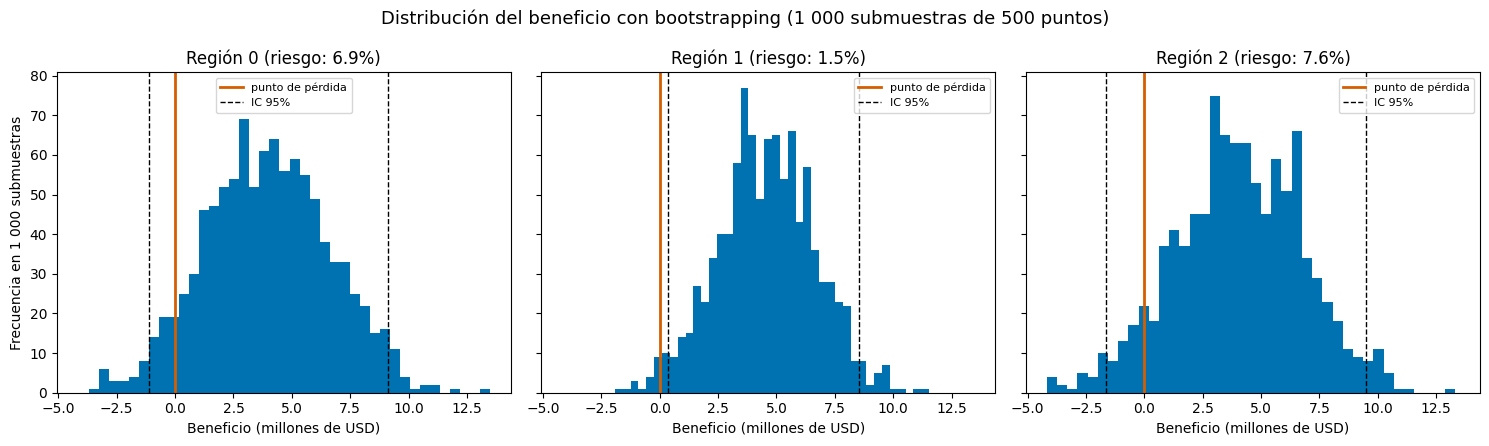

In [70]:
# Graficamos las tres distribuciones de beneficios para comparar su forma y su dispersión
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, (nombre, beneficios_bootstrap) in zip(axes, distribuciones.items()):
    fila = riesgos.loc[nombre]

    ax.hist(beneficios_bootstrap / 1_000_000, bins=40, color='#0072B2')
    # la línea roja marca el punto donde el proyecto deja de ganar y empieza a perder
    ax.axvline(0, color='#D55E00', linewidth=2, label='punto de pérdida')
    ax.axvline(fila['ic_inferior'] / 1_000_000, color='#000000', linestyle='--', linewidth=1, label='IC 95%')
    ax.axvline(fila['ic_superior'] / 1_000_000, color='#000000', linestyle='--', linewidth=1)
    ax.set_title(f'{nombre} (riesgo: {fila["riesgo_pérdidas_%"]:.1f}%)')
    ax.set_xlabel('Beneficio (millones de USD)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Frecuencia en 1 000 submuestras')
fig.suptitle('Distribución del beneficio con bootstrapping (1 000 submuestras de 500 puntos)', fontsize=13)
fig.tight_layout()
plt.show()

In [71]:
# Aplicamos el criterio de la compañía: primero descartamos por riesgo, después elegimos por beneficio
regiones_aptas = riesgos[riesgos['riesgo_pérdidas_%'] < UMBRAL_RIESGO * 100]
region_elegida = regiones_aptas['beneficio_medio'].idxmax()

print('Resumen de la etapa 5')
print('-' * 100)
for nombre, fila in riesgos.iterrows():
    cumple = 'sí' if fila['riesgo_pérdidas_%'] < UMBRAL_RIESGO * 100 else 'no'
    print(
        f'{nombre}: beneficio medio {fila["beneficio_medio"]:,.0f} USD | '
        f'IC 95% [{fila["ic_inferior"]:,.0f} , {fila["ic_superior"]:,.0f}] | '
        f'riesgo {fila["riesgo_pérdidas_%"]:.1f}% | cumple el límite del 2.5%: {cumple}'
    )
print('-' * 100)
print(f'Regiones que cumplen el criterio de riesgo: {list(regiones_aptas.index)}')
print(f'Región recomendada: {region_elegida}')

Resumen de la etapa 5
----------------------------------------------------------------------------------------------------
Región 0: beneficio medio 3,961,650 USD | IC 95% [-1,112,155 , 9,097,669] | riesgo 6.9% | cumple el límite del 2.5%: no
Región 1: beneficio medio 4,560,451 USD | IC 95% [338,205 , 8,522,895] | riesgo 1.5% | cumple el límite del 2.5%: sí
Región 2: beneficio medio 4,044,039 USD | IC 95% [-1,633,504 , 9,503,596] | riesgo 7.6% | cumple el límite del 2.5%: no
----------------------------------------------------------------------------------------------------
Regiones que cumplen el criterio de riesgo: ['Región 1']
Región recomendada: Región 1


**Conclusión de la etapa 5:** al repetir el escenario real (500 puntos explorados, 200 pozos desarrollados) los beneficios se reducen a una fracción de los de la etapa 4 y, sobre todo, aparecen los riesgos.

| Región | Beneficio medio | IC 95 % | Riesgo de pérdidas |
| --- | --- | --- | --- |
| Región 0 | 3 961 650 USD | [-1 112 155 , 9 097 669] | 6.9 % |
| Región 1 | **4 560 451 USD** | [338 205 , 8 522 895] | **1.5 %** |
| Región 2 | 4 044 039 USD | [-1 633 504 , 9 503 596] | 7.6 % |

La región 1 es la única que cumple el límite de 2.5 % de riesgo, y además tiene el beneficio promedio más alto. Su intervalo de confianza es el único que queda por completo en terreno positivo: incluso en el 2.5 % de escenarios más desfavorables, el proyecto gana 338 205 dólares. Las regiones 0 y 2 tienen intervalos que cruzan el cero y pierden dinero en cerca de 7 de cada 100 escenarios, así que quedan descartadas por criterio de la compañía antes de comparar beneficios.

**Esto no coincide con la elección preliminar de la etapa 4**, donde la región 0 encabezaba con 33.2 millones. La diferencia está en cuántos candidatos hay para elegir. Con 25 000 pozos disponibles, la región 0 podía darse el lujo de que su modelo fallara: había tantos pozos buenos que la selección igual atrapaba los mejores. Con solo 500 puntos, un modelo con RMSE de 37.58 confunde pozos buenos con malos y la selección se degrada. La región 1, con un RMSE de 0.89, elige casi sin equivocarse, y esa precisión termina valiendo más que el mayor volumen de las otras dos. En los histogramas se ve con claridad: la distribución de la región 1 es la más estrecha y la única que apenas toca la línea de pérdida.

## Conclusiones generales

El proyecto buscaba en cuál de tres regiones conviene abrir 200 pozos, y la respuesta cambió a medida que el análisis se acercó a las condiciones reales del negocio.

- Los datos no necesitaron limpieza, pero sí revelaron una diferencia de fondo: Las tres regiones traían 100 000 pozos completos y bien tipados. La región 1 resultó atípica: su volumen de reservas toma solo 12 valores distintos, con 8 235 pozos vacíos, frente a las distribuciones continuas de las regiones 0 y 2. Esa rareza, que al principio parecía un detalle, fue determinante al final

- El modelo confirmó esa diferencia: Con regresión lineal, las regiones 0 y 2 arrojaron un RMSE de 37.58 y 40.03, cerca del 85 % y 89 % de la desviación de sus datos: el modelo apenas distingue un pozo bueno de uno malo. La región 1 obtuvo un RMSE de 0.89, un 2 % de su desviación, aunque con el volumen medio más bajo (68.73). Quedó planteado el dilema: más petróleo con predicciones imprecisas, o menos petróleo con predicciones confiables.

- Las condiciones del negocio mostraron que ninguna región es rentable por sí sola: Cada pozo cuesta 500 000 dólares y necesita 111.11 miles de barriles para no dar pérdida, un umbral que ninguna de las tres alcanza en promedio (92.50, 68.83 y 95.00). El negocio no está en la región, sino en la selección.

- Seleccionar los mejores pozos hizo rentables a las tres, pero con un supuesto irreal: Al tomar los 200 mejores de 25 000, los beneficios fueron de 33.2, 24.2 y 27.1 millones, con la región 0 al frente. Ese cálculo asume un lujo que la compañía no tiene: solo explora 500 puntos.

- El bootstrapping cambió el diagnóstico y también la respuesta: Repitiendo 1 000 veces el escenario real, los beneficios promedio caen al rango de 4 millones y aparecen los riesgos: 6.9 % en la región 0 y 7.6 % en la región 2, ambos muy por encima del límite de 2.5 %. La región 1 se queda en 1.5 %.

### Recomendación

- Se recomienda desarrollar los 200 pozos en la región 1:  Es la única que cumple el criterio de riesgo de la compañía y, entre las que lo cumplen, la de mayor beneficio esperado: 4 560 451 dólares, un ROI del 4.6 % sobre los 100 millones invertidos. Su intervalo de confianza del 95 % va de 338 205 a 8 522 895 dólares, es decir, positivo en todo su rango.

- La lección del proyecto es que la métrica del modelo y el resultado del negocio no apuntan al mismo lugar de forma automática. La región 0 tenía más petróleo y ganaba en el cálculo directo, pero su modelo era demasiado impreciso para elegir bien entre 500 candidatos. La precisión de la región 1 vale más que el volumen de la 0 justamente porque la decisión se toma con pocos datos, y es el bootstrapping ,no el RMSE ni el beneficio puntual, el que permite verlo.

- Dos 'advertencias' para la lectura de negocio. Primera: un ROI del 4.6 % deja un margen estrecho, así que el resultado depende de que se sostengan las condiciones asumidas, en particular el precio de 4 500 dólares por unidad. Segunda: el análisis supone que los 500 puntos que se exploren se parecerán a los datos históricos de la región; si la exploración se concentra en una zona distinta, las estimaciones dejan de ser válidas.